# Day 1: Environment Setup & Data Exploration
## Smart City IoT Analytics Pipeline — Hakeem

Run all cells in order using **SparkCity_Capstone/.venv/bin/python** as the notebook kernel. From the repository root, install the locked environment with `uv sync --dev`. Restart the kernel after changing interpreters or after a failed Spark startup.

This notebook initializes local Spark, loads all seven existing raw datasets, assesses quality, explores time patterns, demonstrates explicit schemas and maps observations to generated zones. Its final cells save a new local Day 1 snapshot for Day 2. It does not regenerate raw files or load S2.

S2 connectivity is an optional read-only check using the shared helper and local `secrets/.env`. Local analysis does not require a database connection.

Timestamps and measurement units come from synthetic sources. The processing timezone is explicitly UTC for consistency; this does not establish the source's real-world timezone or authorize unit conversions.


In [1]:
print("🚀 Welcome to the Smart City IoT Analytics Pipeline!")
print("=" * 60)

🚀 Welcome to the Smart City IoT Analytics Pipeline!


In [2]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType, TimestampType
)
from sparkcityx.loaders import load_dataset
from sparkcityx.data_quality import get_validation_config, validate_dataframe

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/sparkcityx").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook from inside SparkCity_Capstone.")
print("Python:", sys.executable)
print("Repository:", ROOT)


Python: /Users/hakeem/Projects/SparkCity_Capstone/.venv/bin/python
Repository: /Users/hakeem/Projects/SparkCity_Capstone


---

# SECTION 1: ENVIRONMENT SETUP (Morning - 2 hours)

---

## 1.1 Initialize local Spark

Java 17 or 21 must be installed. The setup recognizes Homebrew Java 17 on this Mac; other machines should configure `JAVA_HOME` for their installed Java.

Use two local workers and four shuffle partitions for this small lab dataset. Explicitly set the session timezone even if Spark is reusing an existing session.


In [3]:
java_home = Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")
if not os.getenv("JAVA_HOME") and java_home.exists():
    os.environ["JAVA_HOME"] = str(java_home)
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark = (SparkSession.builder
         .appName("SmartCityIoTPipeline-Day1")
         .master("local[2]")
         .config("spark.driver.memory", "2g")
         .config("spark.sql.shuffle.partitions", "4")
         .config("spark.sql.adaptive.enabled", "true")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.conf.set("spark.sql.session.timeZone", "UTC")
spark.sparkContext.setLogLevel("ERROR")
assert spark.range(5).count() == 5
print("Spark:", spark.version)
print("Master:", spark.sparkContext.master)
print("Java home:", os.getenv("JAVA_HOME", "system Java"))
print("Spark UI:", spark.sparkContext.uiWebUrl or "disabled")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/14 09:57:25 WARN Utils: Your hostname, Zipcoders-MacBook-3.local, resolves to a loopback address: 127.0.0.1; using 192.168.88.25 instead (on interface en0)
26/09/14 09:57:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/14 09:57:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 4.2.0
Master: local[2]
Java home: /opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home
Spark UI: http://192.168.88.25:4040


## 1.2 Optional S2 connection check

Set `CHECK_S2 = True` to test the shared PostgreSQL connection. This explicitly loads `secrets/.env` and reads server metadata only. It requires network access and valid credentials; it does not use Spark JDBC or create/load tables.

Leave it disabled for local exploration. A failed optional check reports the exception type without printing credentials and directs you to check the configured secret and network access.


In [4]:
from dotenv import load_dotenv
from sparkcityx.database import check_database_connection

CHECK_S2 = False
db_connected = None
if CHECK_S2:
    load_dotenv(ROOT / "secrets/.env", override=False)
    try:
        status = check_database_connection()
    except Exception as exc:
        db_connected = False
        print("S2 check failed:", type(exc).__name__)
        print("Check secrets/.env, DATABASE_URL, network access and instructor credentials.")
    else:
        db_connected = True
        print("S2 connection OK:", status.as_dict())
else:
    print("Optional S2 check skipped. Local analysis can proceed.")


Optional S2 check skipped. Local analysis can proceed.


## 1.3 Verify local input files

The generator is `scripts/generate-data.py` (with a hyphen). The notebook checks for existing files and never regenerates them automatically.

If files are missing, run `uv run python scripts/generate-data.py --records 36000` from the repository root. That command replaces the generated files in `data/raw`; it does not load S2.


In [5]:
FILES = {
    "city_zones": "city_zones.csv",
    "traffic": "traffic_sensors.csv",
    "air_quality": "air_quality.json",
    "weather": "weather_data.parquet",
    "energy": "energy_meters.csv",
    "occupancy": "occupancy_data.csv",
    "fiscal": "fiscal_data.csv",
}
data_dir = ROOT / "data/raw"
missing = [str(data_dir / filename) for filename in FILES.values()
           if not (data_dir / filename).exists()]
if missing:
    raise FileNotFoundError("Missing input files: " + ", ".join(missing))
data_ready = True
print("All seven local datasets are present:", data_dir)


All seven local datasets are present: /Users/hakeem/Projects/SparkCity_Capstone/data/raw


---

# SECTION 2: DATA EXPLORATION (Morning - 2 hours)

---

In [6]:
print("\n" + "=" * 60)
print("📊 SECTION 2: EXPLORATORY DATA ANALYSIS")
print("=" * 60)


📊 SECTION 2: EXPLORATORY DATA ANALYSIS


## 2.1: Load and Examine Data Sources (45 minutes)

🎯 **TASK:** Load each data source and examine its structure  
💡 **HINT:** Use appropriate Spark readers for different file formats  
📚 **CONCEPTS:** Schema inference, file formats, data types

In [7]:
def inspect_dataset(kind):
    df = load_dataset(spark, data_dir / FILES[kind])
    print(kind, "records:", df.count())
    df.printSchema()
    df.show(5, truncate=False)
    return df


In [8]:
zones_df = inspect_dataset("city_zones")

city_zones records: 36000
root
 |-- zone_id: string (nullable = true)
 |-- zone_name: string (nullable = true)
 |-- zone_type: string (nullable = true)
 |-- lat_min: double (nullable = true)
 |-- lat_max: double (nullable = true)
 |-- lon_min: double (nullable = true)
 |-- lon_max: double (nullable = true)
 |-- population: integer (nullable = true)

+---------+---------------------+-----------+-------+---------+----------+----------+----------+
|zone_id  |zone_name            |zone_type  |lat_min|lat_max  |lon_min   |lon_max   |population|
+---------+---------------------+-----------+-------+---------+----------+----------+----------+
|ZONE-0001|Residential Zone 0001|residential|40.68  |40.680842|-74.05    |-74.049105|3824      |
|ZONE-0002|Commercial Zone 0002 |commercial |40.68  |40.680842|-74.049105|-74.048211|602       |
|ZONE-0003|Industrial Zone 0003 |industrial |40.68  |40.680842|-74.048211|-74.047316|663       |
|ZONE-0004|Mixed Use Zone 0004  |mixed_use  |40.68  |40.680842|-74

In [9]:
traffic_df = inspect_dataset("traffic")

traffic records: 36000
root
 |-- sensor_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- location_lat: double (nullable = true)
 |-- location_lon: double (nullable = true)
 |-- vehicle_count: integer (nullable = true)
 |-- avg_speed: double (nullable = true)
 |-- congestion_level: string (nullable = true)
 |-- road_type: string (nullable = true)

+---------+-------------------+------------+------------+-------------+---------+----------------+-----------+
|sensor_id|timestamp          |location_lat|location_lon|vehicle_count|avg_speed|congestion_level|road_type  |
+---------+-------------------+------------+------------+-------------+---------+----------------+-----------+
|TRF-0001 |2025-01-01 00:00:00|40.680561   |-74.0492    |109          |16.17    |high            |arterial   |
|TRF-0002 |2025-01-01 00:05:00|40.680511   |-74.049047  |81           |31.34    |medium          |highway    |
|TRF-0003 |2025-01-01 00:10:00|40.680129   |-74.047605  |55        

In [10]:
air_quality_df = inspect_dataset("air_quality")

air_quality records: 36000
root
 |-- co: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- location_lat: double (nullable = true)
 |-- location_lon: double (nullable = true)
 |-- no2: double (nullable = true)
 |-- pm10: double (nullable = true)
 |-- pm25: double (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- temperature: double (nullable = true)
 |-- timestamp: string (nullable = true)

+-----+--------+------------+------------+-----+-----+-----+---------+-----------+-------------------+
|co   |humidity|location_lat|location_lon|no2  |pm10 |pm25 |sensor_id|temperature|timestamp          |
+-----+--------+------------+------------+-----+-----+-----+---------+-----------+-------------------+
|0.621|70.27   |40.680182   |-74.049643  |9.24 |32.22|18.82|AIR-0001 |47.69      |2025-01-01 00:00:00|
|1.305|65.02   |40.680809   |-74.047195  |16.88|26.64|22.63|AIR-0002 |50.99      |2025-01-01 00:15:00|
|0.603|64.81   |40.680662   |-74.043872  |24.54|21.71|16.3

In [11]:
weather_df = inspect_dataset("weather")

weather records: 36000
root
 |-- station_id: string (nullable = true)
 |-- timestamp: timestamp_ntz (nullable = true)
 |-- location_lat: double (nullable = true)
 |-- location_lon: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- wind_direction: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- pressure: double (nullable = true)

+----------+-------------------+------------+------------+-----------+--------+----------+--------------+-------------+--------+
|station_id|timestamp          |location_lat|location_lon|temperature|humidity|wind_speed|wind_direction|precipitation|pressure|
+----------+-------------------+------------+------------+-----------+--------+----------+--------------+-------------+--------+
|WTH-0001  |2025-01-01 00:00:00|40.680459   |-74.049119  |51.69      |62.77   |22.56     |287.0         |0.371        |1004.5  |
|WTH-0002  |2025-01-0

In [12]:
energy_df = inspect_dataset("energy")
occupancy_df = inspect_dataset("occupancy")
fiscal_df = inspect_dataset("fiscal")

energy records: 36000
root
 |-- meter_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- building_type: string (nullable = true)
 |-- location_lat: double (nullable = true)
 |-- location_lon: double (nullable = true)
 |-- power_consumption: double (nullable = true)
 |-- voltage: double (nullable = true)
 |-- current: double (nullable = true)
 |-- power_factor: double (nullable = true)

+--------+-------------------+-------------+------------+------------+-----------------+-------+-------+------------+
|meter_id|timestamp          |building_type|location_lat|location_lon|power_consumption|voltage|current|power_factor|
+--------+-------------------+-------------+------------+------------+-----------------+-------+-------+------------+
|ENG-0001|2025-01-01 00:00:00|commercial   |40.680371   |-74.049869  |46.3             |120.77 |38.34  |0.92        |
|ENG-0002|2025-01-01 00:10:00|commercial   |40.680259   |-74.043557  |36.93            |119.85 |30.81  |0.95    

## 2.2: Basic Data Quality Assessment (45 minutes)

🎯 **TASK:** Assess data quality across all datasets  
💡 **HINT:** Check for missing values, duplicates, data ranges  
📚 **CONCEPTS:** Data profiling, quality metrics, anomaly detection

In [13]:
def assess_data_quality(df, dataset_name):
    """Use the shared contract, including primary-key duplicate checks."""
    report = validate_dataframe(df, dataset_name)
    print(dataset_name, {k: v for k, v in report.items() if k != "numeric_summary"})
    if report["numeric_summary"]:
        display(pd.DataFrame(report["numeric_summary"]))
    return report


In [14]:
datasets = {
    "city_zones": zones_df, "traffic": traffic_df, "air_quality": air_quality_df,
    "weather": weather_df, "energy": energy_df, "occupancy": occupancy_df, "fiscal": fiscal_df,
}
quality_reports = {kind: assess_data_quality(df, kind) for kind, df in datasets.items()}
display(pd.DataFrame([{"dataset": k, "rows": r["record_count"], "valid": r["valid"]}
                      for k, r in quality_reports.items()]))
if not all(r["valid"] for r in quality_reports.values()):
    raise ValueError("Resolve the reported quality failures before proceeding.")


city_zones {'dataset_type': 'city_zones', 'valid': True, 'record_count': 36000, 'missing_columns': [], 'non_numeric_columns': [], 'null_counts': {}, 'duplicate_count': 0, 'range_violations': {}, 'value_violations': {}, 'timestamp_violations': {}, 'cross_field_violations': {}}


,summary,lat_min,lat_max,lon_min,lon_max,population
0,count,36000,36000,36000,36000,36000
1,mean,40.75935789444529,40.760200000001056,-73.96555921051029,-73.96466447367668,3022.003583333333
2,stddev,0.04606103919488944,0.046061039701610976,0.049078050635065436,0.049078050635950575,2855.8303511974086
3,min,40.68,40.680842,-74.05,-74.049105,0
4,25%,40.719579,40.720421,-74.007947,-74.007053,612
5,50%,40.759158,40.76,-73.965895,-73.965,2330
6,75%,40.799579,40.800421,-73.922947,-73.922053,4642
7,max,40.839158,40.84,-73.880895,-73.88,12000


traffic {'dataset_type': 'traffic', 'valid': True, 'record_count': 36000, 'missing_columns': [], 'non_numeric_columns': [], 'null_counts': {}, 'duplicate_count': 0, 'range_violations': {}, 'value_violations': {}, 'timestamp_violations': {}, 'cross_field_violations': {}}


,summary,location_lat,location_lon,vehicle_count,avg_speed
0,count,36000,36000,36000,36000
1,mean,40.759780166416846,-73.96510990627756,76.39902777777777,18.92764888888897
2,stddev,0.04606195685717029,0.04907745793114196,36.316692622040215,12.336556079187606
3,min,40.680006,-74.049999,15,5.0
4,25%,40.719898,-74.007667,47,9.55
5,50%,40.759812,-73.965196,74,15.11
6,75%,40.799646,-73.922638,101,24.75
7,max,40.839999,-73.880012,186,61.13


air_quality {'dataset_type': 'air_quality', 'valid': True, 'record_count': 36000, 'missing_columns': [], 'non_numeric_columns': [], 'null_counts': {}, 'duplicate_count': 0, 'range_violations': {}, 'value_violations': {}, 'timestamp_violations': {}, 'cross_field_violations': {}}


...

occupancy {'dataset_type': 'occupancy', 'valid': True, 'record_count': 36000, 'missing_columns': [], 'non_numeric_columns': [], 'null_counts': {}, 'duplicate_count': 0, 'range_violations': {}, 'value_violations': {}, 'timestamp_violations': {}, 'cross_field_violations': {}}


,summary,location_lat,location_lon,available_rooms,occupied_rooms,guests
0,count,36000,36000,36000,36000,36000
1,mean,40.759775263805146,-73.96555554980527,351.77675,251.0930277777778,623.5408333333334
2,stddev,0.046064895366951075,0.04908018347222941,395.222171320007,300.38647474194823,818.563757826967
3,min,40.680001,-74.049999,10,3,3
4,25%,40.719853,-74.008238,40,28,64
5,50%,40.759706,-73.965545,151,100,229
6,75%,40.799675,-73.922743,685,447,928
7,max,40.839983,-73.880895,1250,1250,4924


fiscal {'dataset_type': 'fiscal', 'valid': True, 'record_count': 36000, 'missing_columns': [], 'non_numeric_columns': [], 'null_counts': {}, 'duplicate_count': 0, 'range_violations': {}, 'value_violations': {}, 'timestamp_violations': {}, 'cross_field_violations': {}}


,summary,location_lat,location_lon,expense,revenue
0,count,36000,36000,36000,36000
1,mean,40.75977367575003,-73.96555901969381,94.11226499999964,269.6368230555556
2,stddev,0.04606232801368263,0.049078537962545875,139.74452735722937,359.25486317502913
3,min,40.680005,-74.05,0.0,0.0
4,25%,40.719891,-74.008253,6.13,30.78
5,50%,40.75975,-73.965591,22.95,106.19
6,75%,40.799646,-73.922797,126.56,324.5
7,max,40.839985,-73.880897,499.98,1708.98


,dataset,rows,valid
0,city_zones,36000,True
1,traffic,36000,True
2,air_quality,36000,True
3,weather,36000,True
4,energy,36000,True
5,occupancy,36000,True
6,fiscal,36000,True


## 2.3: Temporal Analysis (30 minutes)

🎯 **TASK:** Analyze temporal patterns in the IoT data  
💡 **HINT:** Look at data distribution over time, identify patterns  
📚 **CONCEPTS:** Time series analysis, temporal patterns, data distribution

In [15]:
print("\n" + "=" * 60) 
print("⏰ TEMPORAL PATTERN ANALYSIS")
print("=" * 60)


⏰ TEMPORAL PATTERN ANALYSIS


+----+------------------+--------+
|hour|      avg_vehicles|readings|
+----+------------------+--------+
|   0| 69.52133333333333|    1500|
|   1| 68.15933333333334|    1500|
|   2| 68.21133333333333|    1500|
|   3| 68.19533333333334|    1500|
|   4|             68.82|    1500|
|   5| 66.65733333333333|    1500|
|   6| 68.08333333333333|    1500|
|   7|104.25333333333333|    1500|
|   8|105.98066666666666|    1500|
|   9| 69.00666666666666|    1500|
|  10|            68.844|    1500|
|  11| 68.98866666666666|    1500|
|  12| 69.62666666666667|    1500|
|  13|             68.74|    1500|
|  14|            67.744|    1500|
|  15| 67.19533333333334|    1500|
|  16|           106.646|    1500|
|  17|107.59666666666666|    1500|
|  18|106.16266666666667|    1500|
|  19|            71.422|    1500|
|  20| 69.54466666666667|    1500|
|  21| 67.12866666666666|    1500|
|  22| 69.45933333333333|    1500|
|  23| 67.58933333333333|    1500|
+----+------------------+--------+

Highest observed ho

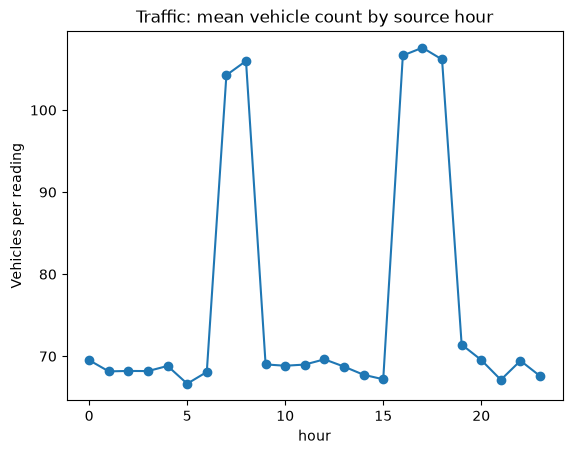

This is a synthetic sample pattern, not total city traffic or causal evidence.


In [16]:
traffic_hourly = (traffic_df.withColumn("hour", F.hour(F.try_to_timestamp("timestamp")))
                  .groupBy("hour")
                  .agg(F.avg("vehicle_count").alias("avg_vehicles"), F.count("*").alias("readings"))
                  .orderBy("hour"))
traffic_hourly.show(24)
peak = traffic_hourly.orderBy(F.desc("avg_vehicles"), "hour").first()
print(f"Highest observed hourly mean: hour {peak['hour']}, {peak['avg_vehicles']:.2f} vehicles/reading.")
traffic_hourly_pd = traffic_hourly.toPandas()
ax = traffic_hourly_pd.plot(x="hour", y="avg_vehicles", marker="o", legend=False,
                           title="Traffic: mean vehicle count by source hour")
ax.set_ylabel("Vehicles per reading")
plt.show()
plt.close(ax.figure)
print("This is a synthetic sample pattern, not total city traffic or causal evidence.")


In [17]:
air_quality_daily = (air_quality_df
    .withColumn("day_of_week", F.dayofweek(F.try_to_timestamp("timestamp")))
    .groupBy("day_of_week")
    .agg(F.avg("pm25").alias("avg_pm25"), F.avg("no2").alias("avg_no2"),
         F.count("*").alias("readings"))
    .orderBy("day_of_week"))
air_quality_daily.show()
print("Spark weekday numbering: Sunday=1, Saturday=7. Values retain source units.")
print("Weekday summaries alone do not establish pollution trends or event effects.")


+-----------+------------------+------------------+--------+
|day_of_week|          avg_pm25|           avg_no2|readings|
+-----------+------------------+------------------+--------+
|          1| 21.11983490566035| 26.60579795597484|    5088|
|          2| 20.95042059748427| 26.58445558176101|    5088|
|          3|20.956096698113228|26.644488993710652|    5088|
|          4|20.969311342592597|26.567878086419732|    5184|
|          5|21.023661265432093|26.742860725308624|    5184|
|          6| 21.21073881172842|26.355862268518525|    5184|
|          7|21.018771219135758| 26.45376350308648|    5184|
+-----------+------------------+------------------+--------+

Spark weekday numbering: Sunday=1, Saturday=7. Values retain source units.
Weekday summaries alone do not establish pollution trends or event effects.


---

# SECTION 3: BASIC DATA INGESTION (Afternoon - 2 hours)

---

In [18]:
print("\n" + "=" * 60)
print("📥 SECTION 3: DATA INGESTION PIPELINE")
print("=" * 60)


📥 SECTION 3: DATA INGESTION PIPELINE


## 3.1: Create Reusable Data Loading Functions (60 minutes)

🎯 **TASK:** Create reusable functions for loading different data formats  
💡 **HINT:** Handle schema validation and error handling  
📚 **CONCEPTS:** Function design, error handling, schema enforcement

In [19]:
def load_csv_data(file_path, expected_schema=None):
    """CSV reader: fail explicitly on malformed input instead of returning None."""
    if expected_schema is None:
        return load_dataset(spark, file_path, file_format="csv")
    return (spark.read.schema(expected_schema).option("header", True)
            .option("enforceSchema", False).option("mode", "FAILFAST").csv(str(file_path)))

def load_json_data(file_path):
    """Shared reader handles both JSON arrays and JSON Lines."""
    return load_dataset(spark, file_path, file_format="json")

def load_parquet_data(file_path):
    return load_dataset(spark, file_path, file_format="parquet")


In [20]:
loader_checks = {}
for kind, reader in [("city_zones", load_csv_data), ("air_quality", load_json_data),
                     ("weather", load_parquet_data)]:
    loaded = reader(data_dir / FILES[kind])
    assert loaded.count() == quality_reports[kind]["record_count"]
    assert validate_dataframe(loaded, kind)["valid"]
    loader_checks[kind] = True
print("CSV, JSON and Parquet reader checks passed.")


CSV, JSON and Parquet reader checks passed.


## 3.2: Schema Definition and Enforcement (60 minutes)

🎯 **TASK:** Define explicit schemas for data consistency  
💡 **HINT:** Use StructType and StructField for schema definition  
📚 **CONCEPTS:** Schema design, data types, schema enforcement

In [21]:
def make_schema(spec):
    # File readers may still produce nullable fields. Shared validation enforces required values.
    return StructType([StructField(name, dtype, True) for name, dtype in spec])

traffic_schema = make_schema([
    ("sensor_id", StringType()), ("timestamp", TimestampType()),
    ("location_lat", DoubleType()), ("location_lon", DoubleType()),
    ("vehicle_count", IntegerType()), ("avg_speed", DoubleType()),
    ("congestion_level", StringType()), ("road_type", StringType()),
])
air_quality_schema = make_schema([
    ("sensor_id", StringType()), ("timestamp", TimestampType()),
    *[(c, DoubleType()) for c in ["location_lat", "location_lon", "pm25", "pm10", "no2",
                                 "co", "temperature", "humidity"]],
])
weather_schema = make_schema([
    ("station_id", StringType()), ("timestamp", TimestampType()),
    *[(c, DoubleType()) for c in ["location_lat", "location_lon", "temperature", "humidity",
                                 "wind_speed", "wind_direction", "precipitation", "pressure"]],
])
energy_schema = make_schema([
    ("meter_id", StringType()), ("timestamp", TimestampType()), ("building_type", StringType()),
    *[(c, DoubleType()) for c in ["location_lat", "location_lon", "power_consumption",
                                 "voltage", "current", "power_factor"]],
])


In [22]:
def load_with_schema(file_path, schema, file_format="csv"):
    if file_format == "csv":
        return load_csv_data(file_path, schema)
    if file_format == "json":
        with Path(file_path).open(encoding="utf-8") as handle:
            first = next((char for chunk in iter(lambda: handle.read(4096), "")
                          for char in chunk if not char.isspace()), "")
        return (spark.read.schema(schema).option("multiLine", first == "[")
                .option("mode", "FAILFAST").json(str(file_path)))
    if file_format == "parquet":
        return spark.read.schema(schema).parquet(str(file_path))
    raise ValueError(f"Unsupported format: {file_format}")

schema_checks = {}
for kind, schema, fmt in [
    ("traffic", traffic_schema, "csv"), ("air_quality", air_quality_schema, "json"),
    ("weather", weather_schema, "parquet"), ("energy", energy_schema, "csv"),
]:
    loaded = load_with_schema(data_dir / FILES[kind], schema, fmt)
    assert loaded.count() == quality_reports[kind]["record_count"]
    assert validate_dataframe(loaded, kind)["valid"], kind
    schema_checks[kind] = True
print("Four explicit-schema reads passed row-count and shared-contract checks.")


Four explicit-schema reads passed row-count and shared-contract checks.


---

# SECTION 4: INITIAL DATA TRANSFORMATIONS (Afternoon - 2 hours)

---

In [23]:
print("\n" + "=" * 60)
print("🔄 SECTION 4: DATA TRANSFORMATIONS")
print("=" * 60)


🔄 SECTION 4: DATA TRANSFORMATIONS


## 4.1: Timestamp Standardization (45 minutes)

🎯 **TASK:** Standardize timestamp formats across all datasets  
💡 **HINT:** Some datasets may have different timestamp formats  
📚 **CONCEPTS:** Date/time handling, format standardization, timezone handling

In [24]:
def standardize_timestamps(df, timestamp_col="timestamp"):
    parsed = df.withColumn(timestamp_col, F.try_to_timestamp(F.col(timestamp_col)))
    if parsed.filter(F.col(timestamp_col).isNull()).limit(1).count():
        raise ValueError(f"Missing or unparseable {timestamp_col}; inspect source data.")
    return (parsed.withColumn("year", F.year(timestamp_col))
            .withColumn("month", F.month(timestamp_col))
            .withColumn("day", F.dayofmonth(timestamp_col))
            .withColumn("hour", F.hour(timestamp_col))
            .withColumn("day_of_week", F.dayofweek(timestamp_col))
            .withColumn("is_weekend", F.dayofweek(timestamp_col).isin(1, 7)))


In [25]:
traffic_std = standardize_timestamps(traffic_df)
assert isinstance(traffic_std.schema["timestamp"].dataType, TimestampType)
assert traffic_std.count() == quality_reports["traffic"]["record_count"]
traffic_std.select("timestamp", "year", "month", "day", "hour", "day_of_week", "is_weekend").show(5)


+-------------------+----+-----+---+----+-----------+----------+
|          timestamp|year|month|day|hour|day_of_week|is_weekend|
+-------------------+----+-----+---+----+-----------+----------+
|2025-01-01 00:00:00|2025|    1|  1|   0|          4|     false|
|2025-01-01 00:05:00|2025|    1|  1|   0|          4|     false|
|2025-01-01 00:10:00|2025|    1|  1|   0|          4|     false|
|2025-01-01 00:15:00|2025|    1|  1|   0|          4|     false|
|2025-01-01 00:20:00|2025|    1|  1|   0|          4|     false|
+-------------------+----+-----+---+----+-----------+----------+
only showing top 5 rows


## 4.2 Map observations to generated zones

Use small geographic bins to limit candidate comparisons, then apply exact rectangular bounds. With 36,000 zones, a full all-pairs spatial join would be unnecessarily expensive.

Rounded coordinates can touch multiple zone boundaries. Preserve one row per observation, record `zone_match_count`, and choose the lowest zone ID deterministically when multiple rectangles match. This is a documented tie rule, not evidence of real geographic ownership. Unmatched observations retain null zone fields.


In [26]:
def map_to_zones(sensor_df, zones, key_columns=("sensor_id", "timestamp"), bin_size=0.002):
    if bin_size <= 0:
        raise ValueError("bin_size must be positive")
    s = (sensor_df.withColumn("_lat_bin", F.floor(F.col("location_lat") / bin_size))
         .withColumn("_lon_bin", F.floor(F.col("location_lon") / bin_size))).alias("s")
    z = (zones.select("zone_id", "zone_name", "zone_type", "lat_min", "lat_max", "lon_min", "lon_max")
         .withColumn("_lat_bin", F.explode(F.sequence(
             F.floor(F.col("lat_min") / bin_size).cast("long"),
             F.floor(F.col("lat_max") / bin_size).cast("long"))))
         .withColumn("_lon_bin", F.explode(F.sequence(
             F.floor(F.col("lon_min") / bin_size).cast("long"),
             F.floor(F.col("lon_max") / bin_size).cast("long"))))).alias("z")
    condition = ((F.col("s._lat_bin") == F.col("z._lat_bin")) &
                 (F.col("s._lon_bin") == F.col("z._lon_bin")) &
                 F.col("s.location_lat").between(F.col("z.lat_min"), F.col("z.lat_max")) &
                 F.col("s.location_lon").between(F.col("z.lon_min"), F.col("z.lon_max")))
    candidates = (s.join(z, condition, "left")
                  .select("s.*", F.col("z.zone_id"), F.col("z.zone_name"), F.col("z.zone_type"))
                  .drop("_lat_bin", "_lon_bin"))
    group = Window.partitionBy(*key_columns)
    return (candidates.withColumn("zone_match_count", F.count("zone_id").over(group))
            .withColumn("_zone_rank", F.row_number().over(group.orderBy(F.col("zone_id").asc_nulls_last())))
            .filter(F.col("_zone_rank") == 1).drop("_zone_rank"))

# Boundary fixture: two matching rectangles produce one output row with match_count=2.
zone_fixture = spark.createDataFrame([
    ("A", "A", "test", 0., .002, 0., .002),
    ("B", "B", "test", .002, .004, 0., .002)],
    "zone_id string, zone_name string, zone_type string, lat_min double, lat_max double, lon_min double, lon_max double")
sensor_fixture = spark.createDataFrame([
    ("s", "2025-01-01", .002, .001), ("outside", "2025-01-01", 1., 1.)],
    "sensor_id string, timestamp string, location_lat double, location_lon double")
mapped_fixture = map_to_zones(sensor_fixture, zone_fixture)
assert mapped_fixture.count() == 2
boundary = mapped_fixture.filter("sensor_id = 's'").first()
assert boundary["zone_match_count"] == 2 and boundary["zone_id"] == "A"
assert mapped_fixture.filter("sensor_id = 'outside'").first()["zone_match_count"] == 0


In [27]:
traffic_with_zones = map_to_zones(traffic_std, zones_df).cache()
assert traffic_with_zones.count() == quality_reports["traffic"]["record_count"]
assert traffic_with_zones.select("sensor_id", "timestamp").distinct().count() == traffic_with_zones.count()
traffic_with_zones.select("sensor_id", "location_lat", "location_lon", "zone_id",
                         "zone_type", "zone_match_count").show(10)
zone_distribution = traffic_with_zones.groupBy("zone_type").count().orderBy(F.desc("count"))
zone_distribution.show()
print("Unmatched observations:", traffic_with_zones.filter("zone_match_count = 0").count())
print("Multiple matching rectangles:", traffic_with_zones.filter("zone_match_count > 1").count())


+---------+------------+------------+----------+-----------+----------------+
|sensor_id|location_lat|location_lon|   zone_id|  zone_type|zone_match_count|
+---------+------------+------------+----------+-----------+----------------+
| TRF-0001|   40.680561|    -74.0492| ZONE-0001|residential|               1|
| TRF-0001|   40.733231|  -74.022605|ZONE-12001|residential|               1|
| TRF-0001|   40.773285|  -73.960519|ZONE-21001|residential|               1|
| TRF-0001|   40.799861|  -74.031687|ZONE-27001|residential|               1|
| TRF-0002|   40.680511|  -74.049047| ZONE-0002| commercial|               1|
| TRF-0002|   40.706699|  -73.949882| ZONE-6002| commercial|               1|
| TRF-0002|   40.733805|  -74.022119|ZONE-12002| commercial|               1|
| TRF-0003|   40.680129|  -74.047605| ZONE-0003| industrial|               1|
| TRF-0003|    40.70615|  -73.949208| ZONE-6003| industrial|               1|
| TRF-0003|   40.746381|  -73.886758|ZONE-15003| industrial|    

## 4.3 Add exploratory quality flags

Use the shared contract's ranges. Avoid inventing a temperature unit or a speed ceiling. These flags supplement the full validator; they do not replace category, timestamp, duplicate or cross-field checks.


In [28]:
def add_data_quality_flags(df, sensor_type):
    config = get_validation_config(sensor_type)
    missing = F.lit(False)
    for c in config["required_columns"]:
        missing = missing | F.col(c).isNull()
    result = df.withColumn("has_missing_values", missing)
    for c, limits in config.get("ranges", {}).items():
        valid = F.col(c).isNotNull() & ~F.isnan(c) & (F.abs(F.col(c)) != float("inf"))
        if "min" in limits:
            valid = valid & (F.col(c) >= limits["min"])
        if "max" in limits:
            valid = valid & (F.col(c) <= limits["max"])
        result = result.withColumn("valid_" + c, F.coalesce(valid, F.lit(False)))
    return result


In [29]:
traffic_with_flags = add_data_quality_flags(traffic_with_zones, "traffic")
traffic_with_flags.select("sensor_id", "avg_speed", "vehicle_count",
                          "valid_avg_speed", "valid_vehicle_count").show(10)
quality_stats = traffic_with_flags.agg(
    F.sum(F.col("valid_avg_speed").cast("long")).alias("valid_speed_count"),
    F.sum(F.col("valid_vehicle_count").cast("long")).alias("valid_vehicle_count_count"),
    F.count("*").alias("total_records"))
quality_stats.show()
assert validate_dataframe(traffic_with_flags, "traffic")["valid"]


+---------+---------+-------------+---------------+-------------------+
|sensor_id|avg_speed|vehicle_count|valid_avg_speed|valid_vehicle_count|
+---------+---------+-------------+---------------+-------------------+
| TRF-0001|    16.17|          109|           true|               true|
| TRF-0001|    11.83|           49|           true|               true|
| TRF-0001|    12.36|           25|           true|               true|
| TRF-0001|     9.15|           91|           true|               true|
| TRF-0002|    31.34|           81|           true|               true|
| TRF-0002|    19.12|           25|           true|               true|
| TRF-0002|    15.33|           40|           true|               true|
| TRF-0003|     15.2|           55|           true|               true|
| TRF-0003|    11.48|           57|           true|               true|
| TRF-0003|    10.41|           24|           true|               true|
+---------+---------+-------------+---------------+-------------

---

# DAY 1 DELIVERABLES & CHECKPOINTS

---

In [30]:
print("\n" + "=" * 60)
print("📋 DAY 1 COMPLETION CHECKLIST")
print("=" * 60)


📋 DAY 1 COMPLETION CHECKLIST


In [31]:
completion_status = {
    "spark_session_created": spark.range(1).count() == 1,
    "seven_datasets_loaded": len(datasets) == 7 and all(r["record_count"] > 0 for r in quality_reports.values()),
    "data_quality_passed": all(r["valid"] for r in quality_reports.values()),
    "loading_functions_checked": len(loader_checks) == 3 and all(loader_checks.values()),
    "explicit_schemas_checked": len(schema_checks) == 4 and all(schema_checks.values()),
    "timestamps_standardized": isinstance(traffic_std.schema["timestamp"].dataType, TimestampType),
    "zone_mapping_preserves_rows": traffic_with_zones.count() == quality_reports["traffic"]["record_count"],
    "quality_flags_added": "valid_avg_speed" in traffic_with_flags.columns,
}
display(pd.DataFrame(completion_status.items(), columns=["checkpoint", "passed"]))
assert all(completion_status.values()), "Review failed local checkpoints."
print("All local Day 1 checkpoints passed.")
print("Optional S2 status:", "skipped" if db_connected is None else ("passed" if db_connected else "failed"))


,checkpoint,passed
0,spark_session_created,True
1,seven_datasets_loaded,True
2,data_quality_passed,True
3,loading_functions_checked,True
4,explicit_schemas_checked,True
5,timestamps_standardized,True
6,zone_mapping_preserves_rows,True
7,quality_flags_added,True


All local Day 1 checkpoints passed.
Optional S2 status: skipped


---

# 🚀 WHAT'S NEXT?

---

## 📅 DAY 2 PREVIEW: Data Quality & Cleaning Pipeline

Tomorrow you'll work on:
1. 🔍 Comprehensive data quality assessment
2. 🧹 Advanced cleaning procedures for IoT sensor data  
3. 📊 Missing data handling and interpolation strategies
4. 🚨 Outlier detection and treatment methods
5. 📏 Data standardization and normalization

## 📚 RECOMMENDED PREPARATION:
- Review PySpark DataFrame operations
- Read about time series data quality challenges
- Familiarize yourself with statistical outlier detection methods

## 💾 SAVE YOUR WORK:
- Commit your notebook to Git
- Document any issues or questions for tomorrow
- Save any custom functions you created

## 🤝 QUESTIONS?
- Post in the class discussion forum
- Review Spark documentation for any unclear concepts
- Prepare questions for tomorrow's Q&A session

## Save the Day 1 → Day 2 handoff

Export all seven datasets as Parquet with consistent timestamp types. Traffic retains zone metadata and match counts; exploratory flags and calendar columns are left out so later stages can recompute them. Each run uses a unique directory. A complete manifest is written only after persisted datasets pass validation and exact content comparison.

Day 2 selects a completed snapshot, verifies file hashes and reports, and records its source run. Running Day 1 again creates another snapshot; existing Day 2/3/4 results retain their old lineage until rerun.

In [32]:
import json
import hashlib
from datetime import datetime, timezone

def input_hash(path):
    """Hash file bytes and relative names, including all files in Parquet directories."""
    digest = hashlib.sha256()
    paths = sorted(path.rglob("*")) if path.is_dir() else [path]
    for item in paths:
        if item.is_file():
            if path.is_dir():
                digest.update(str(item.relative_to(path)).encode())
            with item.open("rb") as handle:
                for block in iter(lambda: handle.read(1024 * 1024), b""):
                    digest.update(block)
    return digest.hexdigest()

DAY1_RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
DAY1_OUTPUT = ROOT / "data/processed/day1" / DAY1_RUN_ID
DAY1_OUTPUT.mkdir(parents=True, exist_ok=False)
source_hashes = {kind: input_hash(data_dir / filename) for kind, filename in FILES.items()}
day1_audit = []
for kind, source in datasets.items():
    required = get_validation_config(kind)["required_columns"]
    if kind == "traffic":
        handoff = traffic_with_zones.select(*required, "zone_id", "zone_name",
                                           "zone_type", "zone_match_count")
    elif "timestamp" in required:
        handoff = standardize_timestamps(source).select(*required)
    else:
        handoff = source.select(*required)
    assert validate_dataframe(handoff, kind)["valid"], kind
    target = DAY1_OUTPUT / kind
    handoff.write.mode("errorifexists").parquet(str(target))
    persisted = spark.read.parquet(str(target))
    report = validate_dataframe(persisted, kind)
    assert report["valid"] and report["record_count"] == quality_reports[kind]["record_count"]
    # Round-trip content check, including zone metadata.
    assert handoff.exceptAll(persisted.select(*handoff.columns)).limit(1).count() == 0
    assert persisted.select(*handoff.columns).exceptAll(handoff).limit(1).count() == 0
    day1_audit.append({"dataset": kind, "rows": report["record_count"],
                      "path": kind, "sha256": input_hash(target),
                      "schema": persisted.schema.jsonValue()})
    print("Exported", kind, report["record_count"], "rows")
assert source_hashes == {k: input_hash(data_dir / f) for k, f in FILES.items()}, "Raw inputs changed during export."
(DAY1_OUTPUT / "quality_assessment.json").write_text(json.dumps(quality_reports, indent=2, default=str))
day1_manifest = {
    "status": "complete", "stage": "day1", "run_id": DAY1_RUN_ID,
    "spark": spark.version, "python": sys.version, "datasets": day1_audit,
    "source_sha256": source_hashes,
    "source_units": {"temperature": None, "avg_speed": None, "power_consumption": None},
    "timestamp_semantics": "source wall-clock parsed with UTC processing setting; actual source timezone unconfirmed",
    "zone_policy": "inclusive rectangles; lowest zone_id wins ties; zone_match_count retained",
}
(DAY1_OUTPUT / "manifest.json").write_text(json.dumps(day1_manifest, indent=2))
print("Day 2 input snapshot:", DAY1_OUTPUT)


Exported city_zones 36000 rows
Exported traffic 36000 rows
Exported air_quality 36000 rows
Exported weather 36000 rows
Exported energy 36000 rows
Exported occupancy 36000 rows
Exported fiscal 36000 rows
Day 2 input snapshot: /Users/hakeem/Projects/SparkCity_Capstone/data/processed/day1/20260914T135810735977Z


In [33]:
traffic_with_zones.unpersist()
print("Day 1 complete. Continue with Hakeem_day2.ipynb.")
# Leave the session available for exploration. Use spark.stop() when finished.


Day 1 complete. Continue with Hakeem_day2.ipynb.
